In [162]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [163]:
from sklearn.datasets import make_classification
import pandas as pd

# Generate 2-feature, 2-class dataset
X, y = make_classification(n_samples=200, n_features=2, n_informative=1, 
                           n_redundant=0,n_classes=2, n_clusters_per_class=1, hypercube=False,
                           class_sep=20, random_state=42)



In [164]:
X[0].shape


(2,)

In [165]:
y

array([0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0])

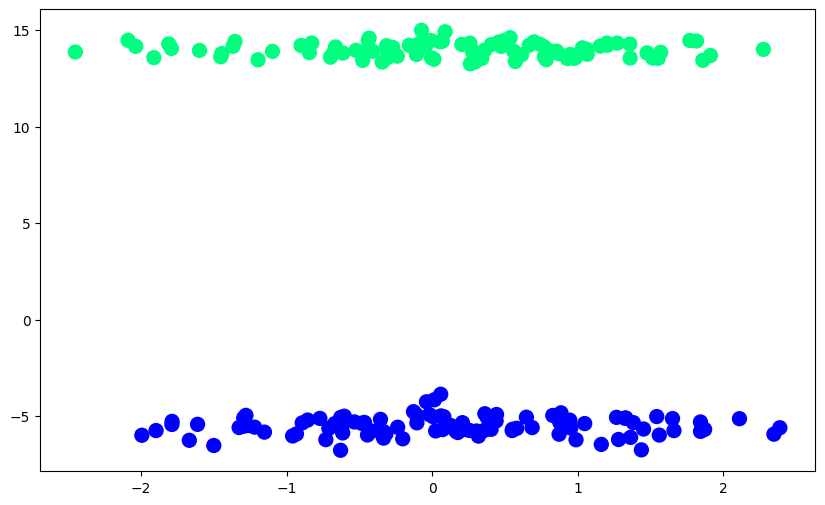

In [166]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.show()

In [167]:
#NOTE: main model prediction funciton : Summation Wi.Xi
def model_pred(p):
    return 1 if p>0 else 0

In [168]:
#NOTE: making : function for perceptron 
def perceptron(X,y):
    X = np.insert(X,0,1, axis=1)
    w = np.ones(X.shape[1])     #NOTE : w : weights
    lr = 0.1    # NOTE: lr  == learning rate

    for j in range(2000):
        j = np.random.randint(0, 200)   #NOTE: selecting random row within total sample 200
        pred_y = model_pred(np.dot(X[j], w))
        w = w + lr * (y[j]-pred_y)* X[j]
    
    return w[0], w[1:]      #NOTE: returning intercept w[0] and coeffi. w1 and w2 that is w[1:]

In [169]:
intercept_, coeff_ = perceptron(X, y)
print(f"The value of Wo is : {intercept_}")
print(f"The value of W1 and W2 is : {coeff_}")

The value of Wo is : 1.0
The value of W1 and W2 is : [1. 1.]


In [170]:
#NOTE: caluating equation for the line 
m = -(coeff_[0] / coeff_[1])       #NOTE : m = -W1 / W2
b = -(intercept_ / coeff_[1])       #NOTE: b = -Wo / W2
print(m,b)

-1.0 -1.0


In [171]:
X_input = np.linspace(-3, 3, 200)
Y_input = m * X_input + b   # NOTE: y = mx + c

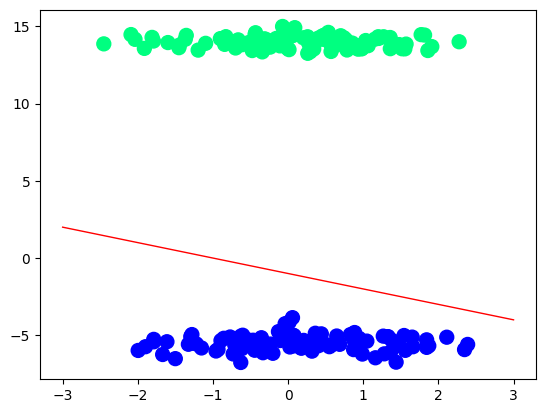

In [172]:
plt.Figure(figsize=(2,1))
plt.plot(X_input, Y_input, color='red', linewidth=1)        #NOTE :plotting line 
plt.scatter(X[:, 0], X[:, 1], c = y, cmap='winter', s=100)


# NOTE: now using LogisticRegression builtin class of sklean


In [173]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(X,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [174]:
m_new = -(LR.coef_[0][0] / LR.coef_[0][1])
b_new = -(LR.intercept_ / LR.coef_[0][1])

In [175]:
x_input = np.linspace(-3, 3 , 200)
y_input = m_new * x_input + b_new 

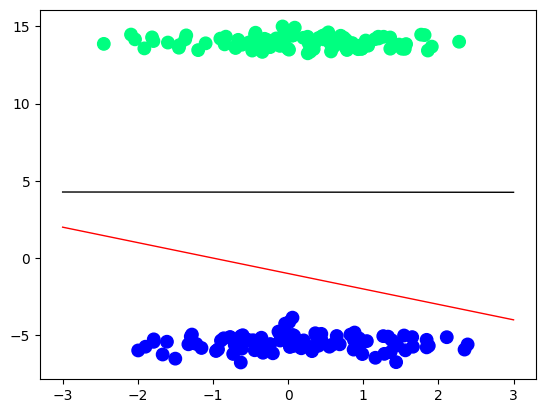

In [176]:
plt.Figure(figsize=(10,6))
plt.plot(X_input, Y_input, color='red', linewidth=1) # NOTE: line via perceptron trick
plt.plot(x_input, y_input, color='black', linewidth=1) #NOTE: line via sklearn's LogisticRegression()
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=80)

# NOW using sigmoid funciton rather than normal robust step function 

In [234]:
import math
def sigmoid(z):
    return 1/(1 + math.exp(-z))

In [235]:
#NOTE: making : function for perceptron 
def perceptron_sigmo(X,y):
    X = np.insert(X,0,1, axis=1)
    w = np.ones(X.shape[1])     #NOTE : w : weights
    lr = 0.1    # NOTE: lr  == learning rate

    for j in range(2000):
        j = np.random.randint(0, 200)   #NOTE: selecting random row within total sample 200
        pred_y = sigmoid(np.dot(X[j], w))
        w = w + lr * (y[j]-pred_y)* X[j]
    
    return w[0], w[1:]      #NOTE: returning intercept w[0] and coeffi. w1 and w2 that is w[1:]

In [236]:
def sigma_gd(z):
    return 1/(1 + np.exp(-z))

In [ ]:
#NOTE: making : function for perceptron 
def gd(X,y):
    X = np.insert(X,0,1, axis=1)
    w = np.ones(X.shape[1])     #NOTE : w : weights
    lr = 0.1    # NOTE: lr  == learning rate

    for j in range(500000):
        pred_y = sigma_gd(np.dot(X, w))
        w = w + lr * (np.dot((y-pred_y), X)/X.shape[0])
    
    return w[0], w[1:]      #NOTE: returning intercept w[0] and coeffi. w1 and w2 that is w[1:]

In [248]:
intercept_, coeff_ = perceptron_sigmo(X, y)
print(f"The value of Wo is : {intercept_}")
print(f"The value of W1 and W2 is : {coeff_}")


gd_intercept_, gd_coeff_ = gd(X, y)
print(f"The value of Wo is : {intercept_}")
print(f"The value of W1 and W2 is : {coeff_}")

The value of Wo is : 0.8585714938379704
The value of W1 and W2 is : [0.86204446 1.74478284]


KeyboardInterrupt: 

In [244]:
#NOTE: caluating equation for the line 
m_sigmoid = -(coeff_[0] / coeff_[1])       #NOTE : m = -W1 / W2
b_sigmoid = -(intercept_ / coeff_[1])       #NOTE: b = -Wo / W2
print(m_sigmoid,b_sigmoid)


#NOTE: caluating equation for the line 
m_gd = -(gd_coeff_[0] / gd_coeff_[1])       #NOTE : m = -W1 / W2
b_gd = -(gd_intercept_ / gd_coeff_[1])       #NOTE: b = -Wo / W2
print(m_gd,b_gd)

-0.48648418512966685 -0.4860797829387752
-0.21564326043196602 -0.16676203350057206


In [245]:
x_sigmoid = np.linspace(-3, 3 , 200)
y_sigmoid = m_sigmoid * x_sigmoid + b_sigmoid 

x_gd = np.linspace(-3, 3 , 200)
y_gd = m_gd * x_gd + b_gd 

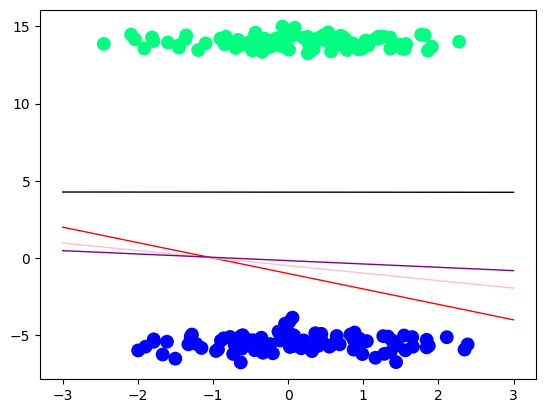

In [246]:
plt.Figure(figsize=(10,6))
plt.plot(X_input, Y_input, color='red', linewidth=1) # NOTE: line via perceptron trick
plt.plot(x_input, y_input, color='black', linewidth=1) #NOTE: line via sklearn's LogisticRegression()
plt.plot(x_sigmoid, y_sigmoid, color='pink', linewidth=1)   #NOTE: line via sigmoid function()
plt.plot(x_gd, y_gd,color='purple', linewidth=1)    #NOTE: line via Gradient descent
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=80)

In [ ]:
#NOTE: here we can see the purple line better than red and pink line theat is perceptron trick based line and sigmoid 
# function based line respectively the purple line can be drawn more accurate as logisticRegression line by increasing the epoch